In [2]:
import warnings
warnings.filterwarnings('ignore')

# Categorical Inputs

# Categorical Variables in Linear Regression

## The Problem: Handling Qualitative Inputs

In real data, not all inputs are numeric. **Categorical (qualitative) variables** take values in a finite set:
- Gender: Male or Female
- Marital status: Single, Married, Divorced
- Ethnicity: Caucasian, African-American, Asian

Linear regression requires numeric inputs, so we need a way to encode categories as numbers.

## Solution: Dummy Variable Encoding

For a binary categorical variable, create a **dummy variable** $x_i$:
$$x_i = \begin{cases} 1 & \text{if individual } i \text{ is Female} \\ 0 & \text{if individual } i \text{ is Male} \end{cases}$$

Now the linear model becomes:
$$y_i = \beta_0 + \beta_1 x_i + \epsilon_i$$

### Interpreting the Model

When $x_i = 0$ (Male):
$$y_i = \beta_0 + \epsilon_i$$
- $\beta_0$ = predicted balance for males (baseline)

When $x_i = 1$ (Female):
$$y_i = (\beta_0 + \beta_1) + \epsilon_i$$
- $\beta_0 + \beta_1$ = predicted balance for females

**Therefore:** $\beta_1$ quantifies the **difference in balance between females and males**.
- If $\beta_1 > 0$: females have higher balance on average
- If $\beta_1 < 0$: females have lower balance on average
- If $\beta_1 = 0$: gender has no effect (null hypothesis)

## Hypothesis Testing for Categorical Variables

We want to test: **Does gender influence credit card balance?**

**Hypotheses:**
- $H_0: \beta_1 = 0$ (gender does NOT influence balance)
- $H_A: \beta_1 \neq 0$ (gender DOES influence balance)

**Test statistic:** The t-statistic
$$t_1 = \frac{\hat{\beta}_1}{\text{SD}(\hat{\beta}_1)}$$

where $\text{SD}(\hat{\beta}_1)$ is the standard error of $\hat{\beta}_1$ (computed from data).

### The Key Insight

Under $H_0$ (true value $\beta_1 = 0$):
- $\hat{\beta}_1$ follows a normal distribution centered at 0
- Scaled by its standard error, $t_1$ follows a **standard normal distribution**
- For a 95% confidence level: if $|t_1| \geq 2$, we reject $H_0$

### Decision Rule
$$|t_1| \geq 2 \implies \text{reject } H_0 \text{ (gender has significant effect)}$$
$$|t_1| < 2 \implies \text{fail to reject } H_0 \text{ (insufficient evidence)}$$

## Example: Credit Card Balance vs. Gender

From the real dataset:

| Parameter | Estimate ($\hat{\beta}$) | Std. Error | t-statistic |
|-----------|-------------------------|-----------|-------------|
| Intercept ($\beta_0$) | 509.80 | 33.13 | 15.389 |
| Gender Female ($\beta_1$) | 19.73 | 46.05 | 0.429 |

**Interpretation:**
- Males (baseline) have predicted balance of \$509.80
- Females have predicted balance of $509.80 + 19.73 = \$529.53$ (only \$19.73 higher)
- t-statistic for gender: $0.429 < 2$
- **Conclusion:** We CANNOT reject $H_0$. Insufficient evidence that gender influences credit card balance.

## Connecting to Previous Topics

$$\text{Coefficient } \hat{\beta}_1 \to \text{Sampling Distribution} \to \text{Standard Error} \to \text{Confidence Interval} \to \text{Hypothesis Test}$$

The same uncertainty framework that gave us confidence intervals now allows us to test whether a variable has a statistically significant effect.

## Key Takeaways

- **Dummy variables convert categorical data into numeric 0/1 encoding.** This allows categorical variables to fit into the linear regression framework.
- **$\beta_1$ represents the difference in predicted outcome between the two groups.** If $\beta_1$ is large, the difference between groups is large.
- **The t-statistic measures signal-to-noise: $t = \hat{\beta} / \text{SE}(\hat{\beta})$.** A large t-statistic means the effect is precisely estimated relative to its uncertainty.
- **Use $|t| \geq 2$ as a rough cutoff for a 95% confidence level.** If $|t| < 2$, the interval includes zero, so we cannot reject $H_0$.
- **Failing to reject $H_0$ does NOT prove the variable has no effect.** It just means we lack sufficient statistical evidence to conclude it does.

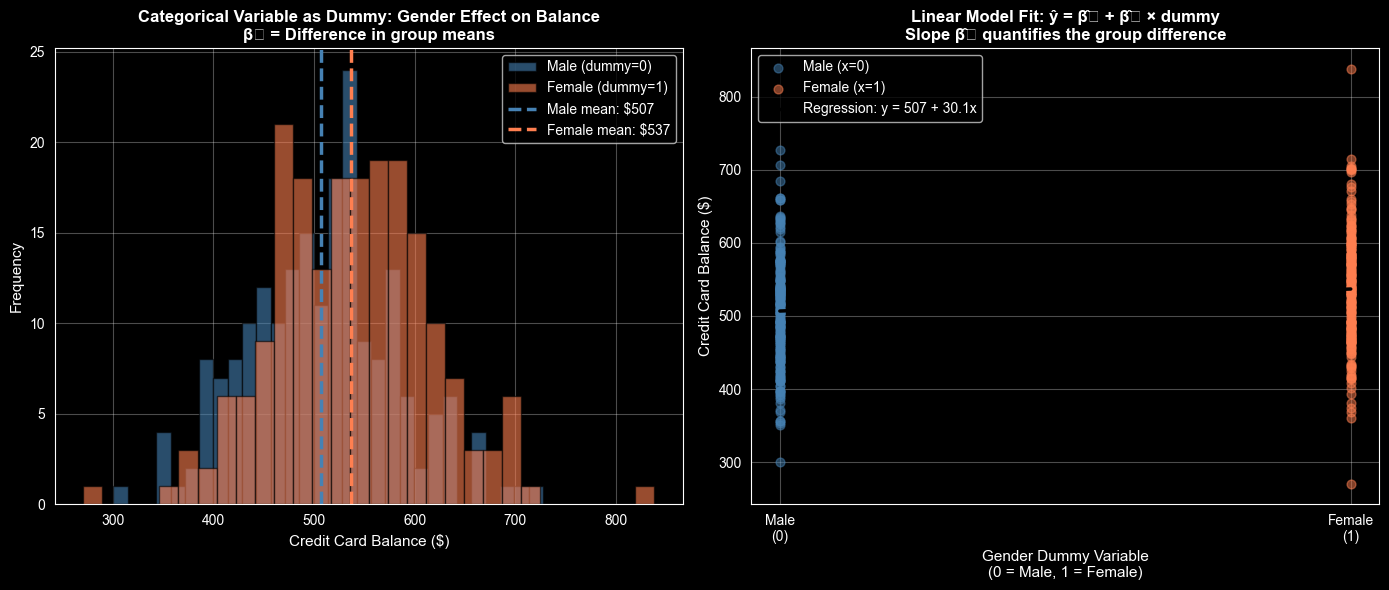

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Simulate credit card balance data
n_males = 200
n_females = 200

# True parameters (for illustration)
beta_0 = 510  # baseline (male intercept)
beta_1 = 20   # gender effect (female increment)
sigma = 80    # noise standard deviation

# Generate data
male_balance = np.random.normal(beta_0, sigma, n_males)
female_balance = np.random.normal(beta_0 + beta_1, sigma, n_females)

# Create dummy variable
balance = np.concatenate([male_balance, female_balance])
gender_dummy = np.concatenate([np.zeros(n_males), np.ones(n_females)])
gender_label = np.array(['Male'] * n_males + ['Female'] * n_females)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Distributions by group
axes[0].hist(male_balance, bins=30, alpha=0.6, label='Male (dummy=0)', color='steelblue', edgecolor='black')
axes[0].hist(female_balance, bins=30, alpha=0.6, label='Female (dummy=1)', color='coral', edgecolor='black')
axes[0].axvline(np.mean(male_balance), color='steelblue', linestyle='--', linewidth=2.5, label=f'Male mean: ${np.mean(male_balance):.0f}')
axes[0].axvline(np.mean(female_balance), color='coral', linestyle='--', linewidth=2.5, label=f'Female mean: ${np.mean(female_balance):.0f}')
axes[0].set_xlabel('Credit Card Balance ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Categorical Variable as Dummy: Gender Effect on Balance\nβ₁ = Difference in group means',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right panel: Dummy variable encoding
axes[1].scatter(gender_dummy[gender_label == 'Male'], male_balance, alpha=0.5,
                s=40, color='steelblue', label='Male (x=0)')
axes[1].scatter(gender_dummy[gender_label == 'Female'], female_balance, alpha=0.5,
                s=40, color='coral', label='Female (x=1)')

# Fit and plot regression line
z = np.polyfit(gender_dummy, balance, 1)
x_line = np.array([0, 1])
y_line = z[0] * x_line + z[1]
axes[1].plot(x_line, y_line, 'k-', linewidth=2.5, label=f'Regression: y = {z[1]:.0f} + {z[0]:.1f}x')

axes[1].set_xlabel('Gender Dummy Variable\n(0 = Male, 1 = Female)', fontsize=11)
axes[1].set_ylabel('Credit Card Balance ($)', fontsize=11)
axes[1].set_title('Linear Model Fit: ŷ = β̂₀ + β̂₁ × dummy\nSlope β̂₁ quantifies the group difference',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Male\n(0)', 'Female\n(1)'], fontsize=10)
axes[1].legend(fontsize=10, loc='upper left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

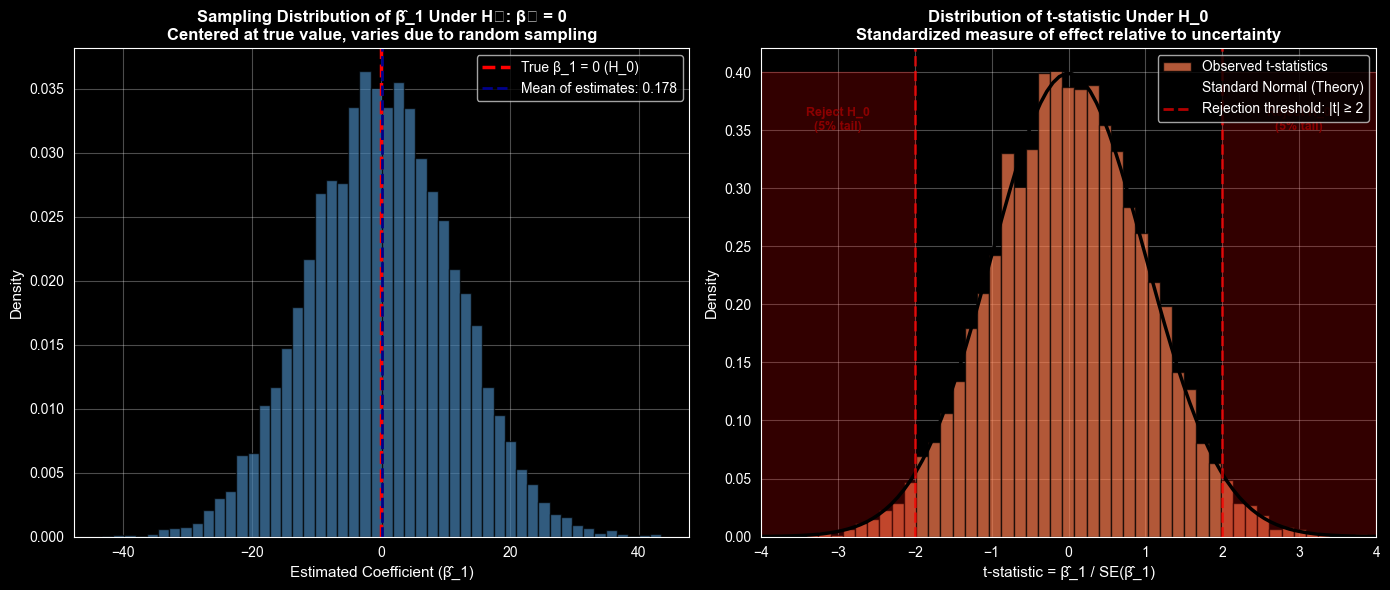

Percentage of |t| ≥ 2 under H_0: 4.57% (should be ~5%)


In [11]:
# Demonstrate the t-test framework under H0: β₁ = 0

# Simulate many experiments under NULL HYPOTHESIS (no true effect)
n_simulations = 10000
n_per_group = 100

# Under H0: both groups have identical distribution (no gender effect)
true_balance_dist = np.random.normal(500, 80, size=(n_simulations, 2*n_per_group))

beta_1_estimates = []
se_beta_1 = []
t_stats = []

for i in range(n_simulations):
    y = true_balance_dist[i]
    x = np.concatenate([np.zeros(n_per_group), np.ones(n_per_group)])

    # Fit regression: y = β₀ + β₁*x
    X = np.column_stack([np.ones(2*n_per_group), x])
    beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

    # Residuals and standard error
    residuals = y - X @ beta_hat
    mse = np.sum(residuals**2) / (2*n_per_group - 2)
    var_beta = mse * np.linalg.inv(X.T @ X)
    se = np.sqrt(var_beta[1, 1])

    beta_1_estimates.append(beta_hat[1])
    se_beta_1.append(se)
    t_stats.append(beta_hat[1] / se)

beta_1_estimates = np.array(beta_1_estimates)
t_stats = np.array(t_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Distribution of β̂₁ under H0
axes[0].hist(beta_1_estimates, bins=50, alpha=0.7, color='steelblue', edgecolor='black', density=True)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2.5, label='True β_1 = 0 (H_0)')
axes[0].axvline(np.mean(beta_1_estimates), color='darkblue', linestyle='--', linewidth=2,
                label=f'Mean of estimates: {np.mean(beta_1_estimates):.3f}')
axes[0].set_xlabel('Estimated Coefficient (β̂_1)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Sampling Distribution of β̂_1 Under H₀: β₁ = 0\nCentered at true value, varies due to random sampling',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right: Distribution of t-statistic under H0
axes[1].hist(t_stats, bins=50, alpha=0.7, color='coral', edgecolor='black', density=True, label='Observed t-statistics')

# Overlay standard normal for reference
t_theory = np.linspace(-4, 4, 100)
normal_pdf = (1/np.sqrt(2*np.pi)) * np.exp(-0.5*t_theory**2)
axes[1].plot(t_theory, normal_pdf, 'k-', linewidth=2.5, label='Standard Normal (Theory)')

# Rejection regions at |t| ≥ 2 (95% CI)
axes[1].axvline(-2, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].axvline(2, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Rejection threshold: |t| ≥ 2')
axes[1].fill_between([-4, -2], [0, 0], [0.4, 0.4], alpha=0.2, color='red')
axes[1].fill_between([2, 4], [0, 0], [0.4, 0.4], alpha=0.2, color='red')
axes[1].text(-3, 0.35, 'Reject H_0\n(5% tail)', fontsize=9, ha='center', fontweight='bold', color='darkred')
axes[1].text(3, 0.35, 'Reject H_0\n(5% tail)', fontsize=9, ha='center', fontweight='bold', color='darkred')

axes[1].set_xlabel('t-statistic = β̂_1 / SE(β̂_1)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Distribution of t-statistic Under H_0\nStandardized measure of effect relative to uncertainty',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10, loc='upper right')
axes[1].grid(alpha=0.3)
axes[1].set_xlim([-4, 4])

plt.tight_layout()
plt.show()

print(f"Percentage of |t| ≥ 2 under H_0: {100 * np.mean(np.abs(t_stats) >= 2):.2f}% (should be ~5%)")

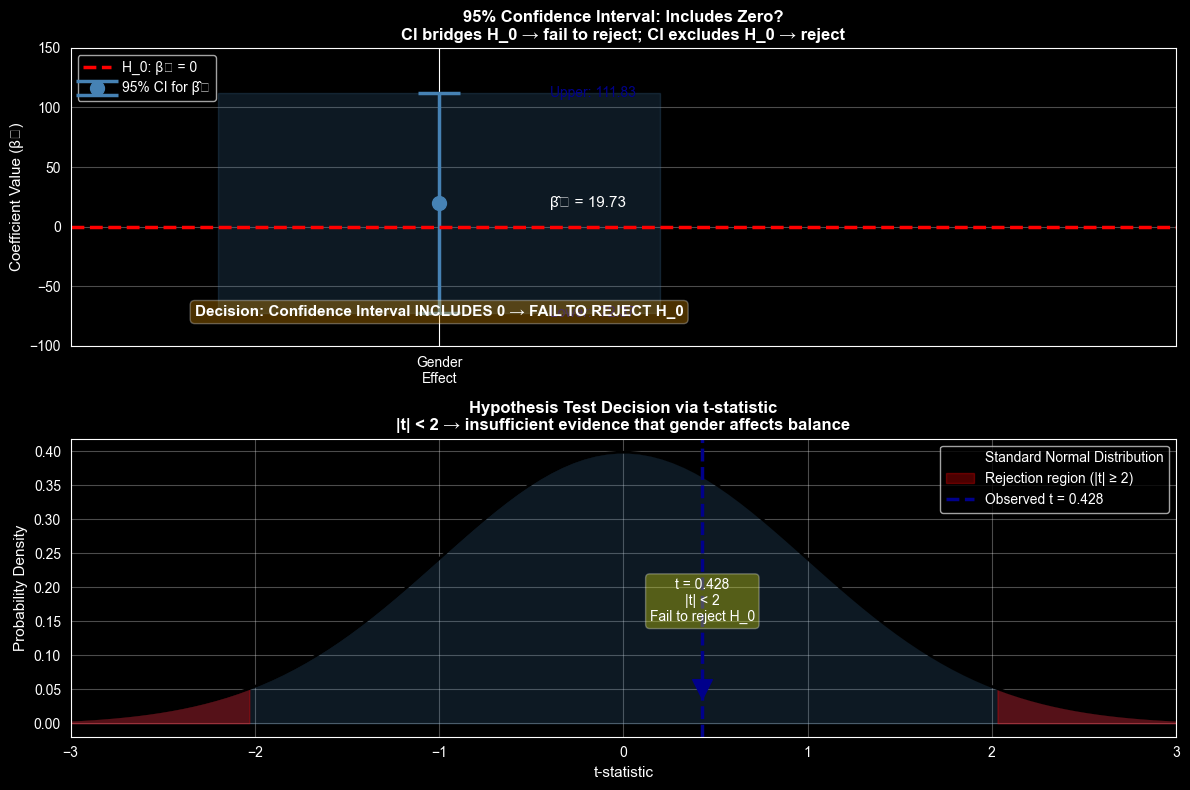


HYPOTHESIS TEST SUMMARY: Does Gender Affect Balance?
Null Hypothesis (H_0):  β₁ = 0 (gender has NO effect)
Alt. Hypothesis (Hₐ):  β₁ ≠ 0 (gender DOES affect balance)

Estimate:              β̂₁ = 19.73
Std. Error:            SE(β̂₁) = 46.05
t-statistic:           t = 0.428
95% CI:                [-72.37, 111.83]

Decision:              Fail to reject H_0 (t = 0.428 < 2)
Conclusion:            Insufficient evidence that gender influences
                       credit card balance (95% confidence level).


In [7]:
# Visualize how confidence intervals relate to hypothesis testing

# Use real data from the example
beta_0_hat = 509.80
beta_1_hat = 19.73
se_beta_1 = 46.05

# Confidence interval (95%)
ci_lower = beta_1_hat - 2 * se_beta_1
ci_upper = beta_1_hat + 2 * se_beta_1

# t-statistic
t_stat = beta_1_hat / se_beta_1

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top panel: Confidence interval visualization
axes[0].errorbar(1, beta_1_hat, yerr=2*se_beta_1, fmt='o', markersize=10,
                 capsize=15, capthick=2.5, color='steelblue', elinewidth=2.5, label='95% CI for β̂_1')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2.5, label='H_0: β₁ = 0')
axes[0].fill_between([0.7, 1.3], ci_lower, ci_upper, alpha=0.2, color='steelblue')

# Annotation showing CI and bounds
axes[0].text(1.15, beta_1_hat, f'β̂_1 = {beta_1_hat:.2f}', fontsize=11, va='center')
axes[0].text(1.15, ci_upper, f'Upper: {ci_upper:.2f}', fontsize=10, va='center', color='darkblue')
axes[0].text(1.15, ci_lower, f'Lower: {ci_lower:.2f}', fontsize=10, va='center', color='darkblue')

axes[0].set_xlim([0.5, 2])
axes[0].set_ylim([-100, 150])
axes[0].set_ylabel('Coefficient Value (β₁)', fontsize=11)
axes[0].set_title('95% Confidence Interval: Includes Zero?\nCI bridges H_0 → fail to reject; CI excludes H_0 → reject',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks([1])
axes[0].set_xticklabels(['Gender\nEffect'], fontsize=10)
axes[0].legend(fontsize=10, loc='upper left')
axes[0].grid(alpha=0.3, axis='y')

# Add decision text
if ci_lower < 0 < ci_upper:
    decision_text = "Decision: Confidence Interval INCLUDES 0 → FAIL TO REJECT H_0"
    decision_color = 'orange'
else:
    decision_text = "Decision: Confidence Interval EXCLUDES 0 → REJECT H_0"
    decision_color = 'green'

axes[0].text(1, -75, decision_text, fontsize=11, ha='center',
            bbox=dict(boxstyle='round', facecolor=decision_color, alpha=0.3), fontweight='bold')

# Bottom panel: t-statistic and rejection region
t_range = np.linspace(-3, 3, 100)
normal_curve = (1/np.sqrt(2*np.pi)) * np.exp(-0.5*t_range**2)

axes[1].plot(t_range, normal_curve, 'k-', linewidth=2, label='Standard Normal Distribution')
axes[1].fill_between(t_range, 0, normal_curve, alpha=0.2, color='steelblue')

# Rejection regions
axes[1].fill_between(t_range[t_range <= -2], 0,
                     normal_curve[t_range <= -2], alpha=0.3, color='red', label='Rejection region (|t| ≥ 2)')
axes[1].fill_between(t_range[t_range >= 2], 0,
                     normal_curve[t_range >= 2], alpha=0.3, color='red')

# Plot observed t-statistic
axes[1].axvline(t_stat, color='darkblue', linestyle='--', linewidth=2.5, label=f'Observed t = {t_stat:.3f}')
axes[1].scatter([t_stat], [0.05], s=200, color='darkblue', zorder=5, marker='v')

# Labels and decision
axes[1].text(t_stat, 0.15, f't = {t_stat:.3f}\n|t| < 2\nFail to reject H_0',
            fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

axes[1].set_xlabel('t-statistic', fontsize=11)
axes[1].set_ylabel('Probability Density', fontsize=11)
axes[1].set_title('Hypothesis Test Decision via t-statistic\n|t| < 2 → insufficient evidence that gender affects balance',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10, loc='upper right')
axes[1].grid(alpha=0.3)
axes[1].set_xlim([-3, 3])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("HYPOTHESIS TEST SUMMARY: Does Gender Affect Balance?")
print("="*60)
print(f"Null Hypothesis (H_0):  β₁ = 0 (gender has NO effect)")
print(f"Alt. Hypothesis (Hₐ):  β₁ ≠ 0 (gender DOES affect balance)")
print(f"\nEstimate:              β̂₁ = {beta_1_hat:.2f}")
print(f"Std. Error:            SE(β̂∫₁) = {se_beta_1:.2f}")
print(f"t-statistic:           t = {t_stat:.3f}")
print(f"95% CI:                [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"\nDecision:              Fail to reject H_0 (t = {t_stat:.3f} < 2)")
print(f"Conclusion:            Insufficient evidence that gender influences")
print(f"                       credit card balance (95% confidence level).")
print("="*60)

3. Quick Understanding Check

Q1: Why do we use a dummy variable (0/1 encoding) instead of using category names directly in the regression?

<details> <summary>Click to reveal answer</summary> Linear regression requires numeric inputs. Dummy variables convert categorical information into numbers that the model can use mathematically. The 0/1 encoding also makes interpretation clean: β₁ becomes the difference in predicted outcome between the two groups. </details>

Q2: In the credit card balance example, the t-statistic for gender is 0.429. What does this tell you, and why is it less than 2?

<details> <summary>Click to reveal answer</summary> The t-statistic measures the signal (estimated effect: 19.73) relative to the noise (standard error: 46.05). A small t means the estimated effect is small compared to its uncertainty. Since 0.429 < 2, the 95% confidence interval includes zero, so we cannot reject the null hypothesis that gender has no effect. </details>

Q3: If the t-statistic had been 2.5 instead of 0.429, what would change in our conclusion?

<details> <summary>Click to reveal answer</summary> If |t| ≥ 2, we would reject H₀ and conclude that gender has a statistically significant effect on balance at the 95% confidence level. The confidence interval would NOT include zero. </details>

Q4: What does "fail to reject H₀" mean? Does it prove that gender has NO effect?

<details> <summary>Click to reveal answer</summary> No. Failing to reject H₀ means we lack sufficient statistical evidence to claim gender influences balance. It does NOT prove no effect exists—we simply don't have strong enough data to detect it. The effect might exist but be too small or hidden by noise to measure precisely. </details>

# More Categorical Inputs

When a categorical variable has **more than 2 levels**, we use **dummy variables**.

### Example: Ethnicity

Suppose ethnicity has 3 categories:
- African American
- Asian
- Caucasian

Choose one category as the **baseline**. Here, African American is the baseline.

### Dummy Variables

For $K$ categories, we need **$K-1$ dummy variables**.

Here:

$$
K=3 \quad \Rightarrow \quad K-1=2
$$

Define:

- $X_1 = 1$ if Asian, 0 otherwise
- $X_2 = 1$ if Caucasian, 0 otherwise

### Linear Model

$$
Balance_i = \beta_0 + \beta_1X_{i1} + \beta_2X_{i2} + \epsilon_i
$$

This creates three cases:

| Ethnicity | Expected Balance          |
|---|---------------------------|
| African American (baseline) | $\beta_0+ \epsilon_i$|
| Asian | $\beta_0+\beta_1 + \epsilon_i$ |
| Caucasian | $\beta_0+\beta_2 + \epsilon_i$|

**Key interpretation:**
- $\beta_0$ = average balance for the baseline group
- $\beta_1$ = difference between Asian and baseline
- $\beta_2$ = difference between Caucasian and baseline

### Hypothesis Testing

To test whether ethnicity affects balance:

$$
H_0:\beta_j=0
$$

$$
H_A:\beta_j\neq0
$$

The test statistic is:

$$
t=\frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}
$$

A common rule of thumb:

- $|t| \lesssim 2$ → insufficient evidence to reject $H_0$
- $|t| > 2$ → evidence against $H_0$

### Key Takeaways

- A categorical variable with $K$ levels needs **$K-1$ dummy variables**.
- One category is chosen as the **baseline/reference group**.
- Each coefficient measures the difference from the baseline.
- A coefficient of 0 means there is no estimated difference from the baseline.
- The **t-statistic** helps determine whether the estimated difference is statistically significant.

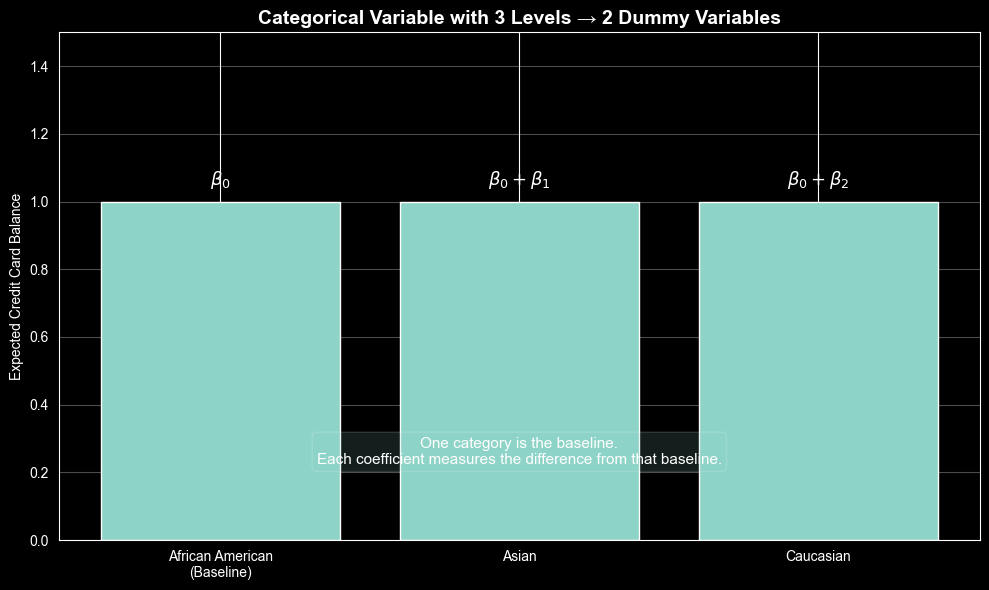

In [10]:
import matplotlib.pyplot as plt

ethnicities = ["African American\n(Baseline)", "Asian", "Caucasian"]
expressions = [r"$\beta_0$", r"$\beta_0+\beta_1$", r"$\beta_0+\beta_2$"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(ethnicities, [1, 1, 1])
ax.set_ylim(0, 1.5)
ax.set_ylabel("Expected Credit Card Balance")
ax.set_title("Categorical Variable with 3 Levels → 2 Dummy Variables",
             fontsize=14, fontweight="bold")

for i, expr in enumerate(expressions):
    ax.text(i, 1.05, expr, ha="center", fontsize=13)

ax.text(
    0.5, 0.15,
    "One category is the baseline.\n"
    "Each coefficient measures the difference from that baseline.",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    bbox=dict(boxstyle="round", alpha=0.15)
)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()